# Validation: Refactored Hardware Backend

This notebook validates that the refactored `hardware/` module maintains **full compatibility** with the original API.



## 1. Setup

In [13]:
import sys
import os
import numpy as np
import time
from pynq import PL 

sys.path.insert(0, os.path.join(os.getcwd(), 'fireq_utils'))
from backend import FireqHardwareBackend
from backend import (
    DMATimeoutError, 
    TimingError, 
    ConfigurationError,
    DriverError
)

from FIREQ_LL_API.overlay_driver import FIREQ_SoC

BITSTREAM_PATH = "/home/xilinx/jupyter_notebooks/api_test_giorgio/fireq_ol/NEW_FIREQ.bit"
if not os.path.exists(BITSTREAM_PATH):
    raise FileNotFoundError(f"Bitstream not found at {BITSTREAM_PATH}!")

print("All imports successful!")

All imports successful!


In [14]:
# Reset PL before loading
PL.reset()
print("PL reset complete.")

PL reset complete.


## 2. Load Overlay & Initialize Backend

In [15]:
print("--- LOADING OVERLAY ---")
overlay = FIREQ_SoC(BITSTREAM_PATH)
print("--- OVERLAY LOADED ---")

--- LOADING OVERLAY ---
--- OVERLAY LOADED ---


In [4]:
print("--- INIT BACKEND ---")
try:
    backend = FireqHardwareBackend(overlay, debug= True)
    print("Backend Object Created.")
    
    # Show how many IPs are available
    print(f"\nHardware Inventory:")
    print(f"  SignalGeneratorIPs: {len(backend.hw.gens)}")
    print(f"  AcquisitionIPs: {len(backend.hw.acqs)}")
    
except Exception as e:
    print(f"!!! CRITICAL FAIL IN INIT: {e}")
    raise e
print("Backend Initialization completed!")


[Backend] INFO: Initializing Backend...
[Backend] DEBUG: Step 1: Discovering hardware via HardwareInventory...
[Backend] DEBUG: HardwareInventory: Scanning overlay for IPs...
[Backend] DEBUG:   Phase 1: Discovering custom IPs...
[Backend] DEBUG:     [OK] Found 1 Signal Generator(s)
[Backend] DEBUG:     [OK] Found 2 Acquisition IP(s)
[Backend] DEBUG:     [OK] Found Trigger Generator
[Backend] DEBUG:   Phase 2: Discovering infrastructure IPs...
[Backend] DEBUG:     [OK] Found AXI DMA Controller
[Backend] DEBUG:     [OK] Found RF-DC Controller
[Backend] DEBUG:     [OK] Found AXI Switch
[Backend] DEBUG: Validating RF clocks and discovering sample rates...
[Backend] DEBUG:   Scanning DAC tiles...


--- INIT BACKEND ---


[Backend] DEBUG:     [OK] DAC Tile 0: 9.585 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] DAC Tile 1: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [OK] DAC Tile 2: 9.585 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] DAC Tile 3: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:   [OK] DAC sample rate: 9.585 GSPS
[Backend] DEBUG:   Scanning ADC tiles...
[Backend] DEBUG:     [OK] ADC Tile 0: 4.792 GSPS (Lock: 2)
[Backend] DEBUG:     [SKIP] ADC Tile 1: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [SKIP] ADC Tile 2: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:     [SKIP] ADC Tile 3: Not active or PLL read failed (RuntimeError)
[Backend] DEBUG:   [OK] ADC sample rate: 4.792 GSPS
[Backend] INFO: Clocks Validated. DAC: 9.585 GSPS, ADC: 4.792 GSPS
[Backend] DEBUG: Hardware specs populated: DAC 9.585G, ADC 4.792G
[Backend] DEBUG: Step 2: Creating GeneratorAdapters...
[Backend] DEBUG: Step 3: Creating AcquisitionAdapters...
[Backend

Backend Object Created.

Hardware Inventory:
  SignalGeneratorIPs: 1
  AcquisitionIPs: 2
Backend Initialization completed!


## 3. API Compatibility Tests



In [5]:
# TEST 1: Properties DAC_SR and ADC_SR
print("TEST 1: Sample Rate Properties")
print(f"  DAC_SR: {backend.DAC_SR / 1e9:.3f} GSPS")
print(f"  ADC_SR: {backend.ADC_SR / 1e9:.3f} GSPS")

print("  PASSED")

TEST 1: Sample Rate Properties
  DAC_SR: 9.585 GSPS
  ADC_SR: 4.792 GSPS
  PASSED


In [6]:
# TEST 2: Access to hw attribute (HardwareInventory)
print("TEST 2: Hardware Inventory Access (backend.hw)")
print(f"  Generators: {len(backend.hw.gens)}")
print(f"  Acquisitions: {len(backend.hw.acqs)}")
print(f"  Trigger: {backend.hw.trig is not None}")


print("   PASSED")

TEST 2: Hardware Inventory Access (backend.hw)
  Generators: 1
  Acquisitions: 2
  Trigger: True
   PASSED


In [7]:
# TEST 3: get_acquisition() returns object with AxiLiteInterfaceMMIO
# This is CRITICAL - the original notebook accesses this directly!
print("TEST 3: get_acquisition() - AxiLiteInterfaceMMIO access")

acq = backend.get_acquisition('Readout_Line')
print(f"  Returned type: {type(acq).__name__}")

# This is the critical test - the notebook does exactly this:
# acq.AxiLiteInterfaceMMIO.read(0x00)
assert hasattr(acq.driver, 'AxiLiteInterfaceMMIO'), "Must have AxiLiteInterfaceMMIO attribute"

# Try to actually read from it
ctrl_reg = acq.driver.AxiLiteInterfaceMMIO.read(0x00)
print(f"  Control Register: 0x{ctrl_reg:08X}")
print("   PASSED - AxiLiteInterfaceMMIO accessible")

TEST 3: get_acquisition() - AxiLiteInterfaceMMIO access
  Returned type: AcquisitionAdapter
  Control Register: 0x00000000
   PASSED - AxiLiteInterfaceMMIO accessible


In [8]:
# TEST 4: Logical map contains expected labels
print("TEST 4: Logical Map")
print(f"  Available labels: {list(backend.logical_map.keys())}")

assert 'Readout_Line' in backend.logical_map, "Should have 'Readout_Line'"
assert 'Qubit_0' in backend.logical_map, "Should have 'Qubit_0'"
print("   PASSED")

TEST 4: Logical Map
  Available labels: ['Readout_Line', 'Qubit_0']
   PASSED


In [9]:
# TEST 5: configure_readout() method signature
print("TEST 5: configure_readout()")

# This is the exact call from the original notebook
backend.configure_readout_pulse(
    freq=200.0, 
    phase=0.0, 
    duration_samples=500,
    amp=0.5, 
    shape='rectangular', 
    target_label='Readout_Line'
)
print("  configure_readout_pulse() called successfully")
print("   PASSED")

[Backend] DEBUG: Readout: 200.0MHz, 500smp


TEST 5: configure_readout()
  configure_readout_pulse() called successfully
   PASSED


In [10]:
# TEST 6: start_experiment() with exact same readout_cfg structure
print("TEST 6: start_experiment()")

# This is the exact call from the original notebook
data = backend.start_experiment(
    duration_cycles=1500,
    readout_cfg={
        'target_label': 'Readout_Line',
        'num_samples': 500,
        'freq': 200.0,
        'mode': 'decimated'
    },
    skip_validation=False
)

print(f"  Returned data shape: {data.shape}")
print(f"  Expected shape: (500,)")

assert data is not None, "Should return data"
assert data.shape[0] == 500, f"Expected 500 samples, got {data.shape[0]}"
print("   PASSED")

[Backend] DEBUG: Timing validated: dur=1500, delay=50, tof=1, acq=1000
[Backend] DEBUG: DMA busy/halted after stop. Forcing reset.


TEST 6: start_experiment()


[Backend] INFO: Armed: 'Readout_Line' [Gen0->ADC1] (Trig Ch1)
[Backend] DEBUG: Trigger fired: Dur=1500, Shots=1
[Backend] INFO: Acquired: (500,) samples


  Returned data shape: (500,)
  Expected shape: (500,)
   PASSED


In [11]:
# TEST 7: MMIO access after experiment (as done in original notebook)
print("TEST 7: MMIO access after experiment")

# This is exactly what the original notebook does
acq = backend.get_acquisition('Readout_Line')
adur = (acq.driver.AxiLiteInterfaceMMIO.read(0x00) >> 2) & 0x3FFF
print(f"  ADC Duration from register: {adur + 1} cycles")
print("   PASSED")

TEST 7: MMIO access after experiment
  ADC Duration from register: 500 cycles
   PASSED


## 4. Visual Validation (same as original notebook)

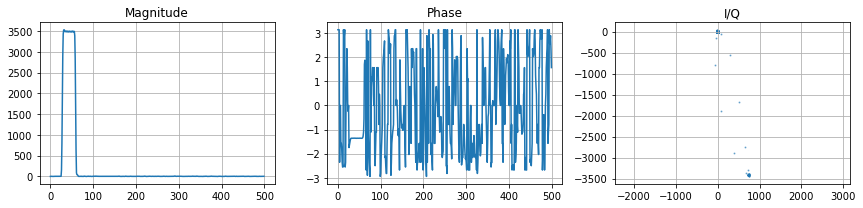

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(np.abs(data))
axes[0].set_title('Magnitude')
axes[0].grid(True)

axes[1].plot(np.angle(data))
axes[1].set_title('Phase')
axes[1].grid(True)

axes[2].scatter(data.real, data.imag, s=1, alpha=0.5)
axes[2].set_title('I/Q')
axes[2].grid(True)
axes[2].axis('equal')

plt.tight_layout()
plt.show()

## 5. New Features (optional)

